# 15 Supervised Learning with Gradient Boosting

Scikit-learn provides two powerful gradient boosting models for supervised learning: `GradientBoostingClassifier` and `GradientBoostingRegressor`. These models are used for classification and regression tasks. Both models use boosting, which involves combining the predictions of several base estimators to improve robustness and accura.cy


# Gradient Boosting Overview

Gradient boosting builds models sequentially, each new model attempting to correct the errors made by the previous models. The models are combined to produce a final strong model. The process can be summarized as:

* Initialize the model with a constant value.
* Iteratively fit base learners to the residual errors of the combined model.

The key idea is to minimize a loss function $L(y, F_m(x))$ by adding a new model $h_m(x)$ that reduces the errors of the combined model $F_{m-1}(x)$ from the previous iteration.

The combined model at iteration $m$ can be written as:

$$
F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)
$$

where:
* $F_{m-1}(x)$ is the combined model after $m-1$ iterations.
* $h_m(x)$ is the new base learner fitted to the residuals.
* $\gamma_m$ is the learning rate conbution of $h_m(x)$.trolling the contri


# GradientBoostingClassifier

For classification tasks, the `GradientBoostingClassifier` minimizes the logistic loss function. The algorithm works as follows:

* Initialize the model with a constant value:

$$
F_0(x) = \arg \min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)
$$

For binary classification, this could be the log odds of the positive class.

* Iterate to fit $M$ base learners:

- Compute the residuals for the current combined model:

$$
r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F = F_{m-1}}
$$

- Fit a new base learner $h_m(x)$ to the residuals $r_{im}$.


- Upate the model:d

$$
F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)
$$

# GradientBoostingRegressor

For regression tasks, the `GradientBoostingRegressor` minimizes the mean squared error (MSE) loss function. The algorithm proceeds similarly to the classifier:

* Initialize the model with a constant value:

$$
F_0(x) = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

* Iterate to fit $M$ base learners:

- Compute the residuals** for the current combined model:

$$
r_{im} = y_i - F_{m-1}(x_i)
$$

- Fit a new base learner $h_m(x)$ to the residuals $r_{im}$.
- Update the combined model:

$$
F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)
$$

# Hyperparameters

Key hyperparameters in gradient boosting include:

- `n_estimators`: The number of boosting stages.
- `learning_rate`: Controls the contribution of each base learner.
- `max_depth`: The maximum depth of the individual base learners (decision trees).
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node.



# Load data

I'm going to redo my categorical dataprep in this assignment.


Just like in my original dataprep, I'm going to start off by removing most rows and a few columns. The ab_id column is in e notation and the code column is a version of my target column, type, where X (other) is expanded into different types of outcomes. Since I'm only concerned with balls and strikes, I dropped that column and all rows where 'type' = X.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('pitches.csv')
df = df[df['type'] != 'X']
df.head()

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.416,2.963,92.9,84.1,2305.052,159.235,-25.0,3.2,23.7,7.665,...,3,0.0,2.015000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.191,2.347,92.8,84.1,2689.935,151.402,-40.7,3.4,23.7,12.043,...,4,0.0,2.015000e+09,0.0,1.0,0.0,2.0,0.0,0.0,0.0
2,-0.518,3.284,94.1,85.2,2647.972,145.125,-43.7,3.7,23.7,14.368,...,5,0.0,2.015000e+09,0.0,2.0,0.0,3.0,0.0,0.0,0.0
3,-0.641,1.221,91.0,84.0,1289.590,169.751,-1.3,5.0,23.8,2.104,...,6,0.0,2.015000e+09,0.0,2.0,0.0,4.0,0.0,0.0,0.0
4,-1.821,2.083,75.4,69.6,1374.569,280.671,18.4,12.0,23.8,-10.280,...,7,0.0,2.015000e+09,1.0,2.0,0.0,5.0,0.0,0.0,0.0


In [5]:
df.columns

Index(['px', 'pz', 'start_speed', 'end_speed', 'spin_rate', 'spin_dir',
       'break_angle', 'break_length', 'break_y', 'ax', 'ay', 'az', 'sz_bot',
       'sz_top', 'type_confidence', 'vx0', 'vy0', 'vz0', 'x', 'x0', 'y', 'y0',
       'z0', 'pfx_x', 'pfx_z', 'nasty', 'zone', 'code', 'type', 'pitch_type',
       'event_num', 'b_score', 'ab_id', 'b_count', 's_count', 'outs',
       'pitch_num', 'on_1b', 'on_2b', 'on_3b'],
      dtype='object')

In [9]:
print(len(df))
df = df.drop('ab_id', axis=1)
df = df.drop('code', axis=1)
df=df.dropna()
len(df)

2353991


2341106

In [12]:
df = df.sample(frac=0.001, random_state=773)
df.reset_index(drop=True, inplace=True)
len(df)

2341

In [14]:
df.describe()

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,zone,event_num,b_score,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
count,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,...,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000
mean,-0.018296,2.245417,88.390047,81.334985,1741.184493,179.531227,5.539598,6.532294,23.815207,-2.123306,...,10.152072,311.088424,2.251175,0.842375,0.836395,0.979923,2.794959,0.298590,0.176848,0.089278
std,0.946217,0.991297,6.001451,5.316808,698.911480,67.010870,24.846219,2.889801,0.064842,10.872609,...,3.956487,191.948191,2.550709,0.953813,0.816062,0.815988,1.703890,0.457738,0.381621,0.285206
min,-5.726000,-1.224045,65.400000,59.800000,17.434000,0.310000,-62.000000,1.700000,23.500000,-26.356587,...,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,-0.679000,1.597000,84.200000,77.700000,1235.830000,136.298000,-12.700000,4.300000,23.800000,-11.587000,...,7.000000,147.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,0.010453,2.265000,89.700000,82.500000,1875.606000,195.132000,5.800000,5.900000,23.800000,-2.623000,...,12.000000,297.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000
75%,0.616102,2.888680,93.000000,85.400000,2279.727000,225.050000,27.200000,8.100000,23.900000,6.444000,...,13.000000,462.000000,3.000000,1.000000,2.000000,2.000000,4.000000,1.000000,0.000000,0.000000
max,5.406000,6.340000,101.500000,94.300000,4417.527000,359.818000,59.800000,17.300000,24.000000,40.978000,...,14.000000,1078.000000,16.000000,3.000000,2.000000,2.000000,11.000000,1.000000,1.000000,1.000000


In [16]:
df['type'].value_counts()

type
S    1310
B    1031
Name: count, dtype: int64

In [18]:
df['type'].value_counts(normalize=True)

type
S    0.55959
B    0.44041
Name: proportion, dtype: float64

# Bin target levels

Typically classification models perform better when there are fewer levels. Levels need to be binned in a sensible manner. Fewer levels results in fewer ways to be incorrect.

In [20]:
df['type'] = (df['type'] != 'B') + 0
df['type'].value_counts()

type
1    1310
0    1031
Name: count, dtype: int64

0 is a ball and 1 is a strike.

# Partition the data

In [23]:
import numpy as np
list_partition = [
    'Train','Validation','Test'
]
df['partition'] = np.random.choice(
    a = list_partition,
    size = df.shape[0]
)

In [25]:
df['partition'].value_counts()

partition
Test          836
Validation    777
Train         728
Name: count, dtype: int64

# Address missing values 

They were dropped at the beginning. Around 10,000 out of 2.3 million rows had a column with missing data so I just removed them before I did my sampling. 

# Prepare data

* 'on_1b','on_2b','on_3b', are binary columns and do not need to be converted to dummy variables.
* 'zone','b_count','s_count','outs' are categorical variables coded as integers and need to be converted to dummy variables.
* Monotonic transformations of numeric data will not improve tree model performance. The numeric data does not need to be modified.

In [30]:
list_categorical = [
    'zone','pitch_type','b_count','s_count','outs',
]
list_numeric = [
    'px','pz','start_speed','end_speed','spin_dir','break_angle','break_length','break_y',
    'ax','ay','az','sz_bot','sz_top','type_confidence','vx0','vy0',
    'vz0','x','x0','y','y0','z0','pfx_x','pfx_z',
    'nasty','event_num','b_score','pitch_num', 'spin_rate'
]
df[list_categorical].describe()

,zone,b_count,s_count,outs
count,2341.000000,2341.000000,2341.000000,2341.000000
mean,10.152072,0.842375,0.836395,0.979923
std,3.956487,0.953813,0.816062,0.815988
min,1.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,0.000000
50%,12.000000,1.000000,1.000000,1.000000
75%,13.000000,1.000000,2.000000,2.000000
max,14.000000,3.000000,2.000000,2.000000


In [32]:
df = pd.get_dummies(
    data = df,
    columns = [
        'zone','pitch_type','b_count','s_count','outs',
    ],
    dtype = 'int'
)

In [34]:
df.head()

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,b_count_0.0,b_count_1.0,b_count_2.0,b_count_3.0,s_count_0.0,s_count_1.0,s_count_2.0,outs_0.0,outs_1.0,outs_2.0
0,-0.045,0.865,85.4,78.6,617.530,176.972,-2.8,7.5,23.8,0.281,...,1,0,0,0,1,0,0,0,1,0
1,0.172,1.376,84.6,77.5,615.133,124.617,-8.5,8.2,23.8,4.323,...,1,0,0,0,1,0,0,0,0,1
2,0.300,3.370,92.3,84.1,2273.173,206.377,28.4,3.6,23.7,-9.410,...,1,0,0,0,1,0,0,0,1,0
3,-0.577,2.778,82.7,75.6,467.748,86.053,-8.4,9.2,23.7,3.899,...,1,0,0,0,0,1,0,1,0,0
4,-0.259,2.400,76.6,71.5,1080.727,278.126,14.1,10.9,23.9,-8.285,...,0,1,0,0,1,0,0,1,0,0


In [38]:
df.columns

Index(['px', 'pz', 'start_speed', 'end_speed', 'spin_rate', 'spin_dir',
       'break_angle', 'break_length', 'break_y', 'ax', 'ay', 'az', 'sz_bot',
       'sz_top', 'type_confidence', 'vx0', 'vy0', 'vz0', 'x', 'x0', 'y', 'y0',
       'z0', 'pfx_x', 'pfx_z', 'nasty', 'type', 'event_num', 'b_score',
       'pitch_num', 'on_1b', 'on_2b', 'on_3b', 'partition', 'zone_1.0',
       'zone_2.0', 'zone_3.0', 'zone_4.0', 'zone_5.0', 'zone_6.0', 'zone_7.0',
       'zone_8.0', 'zone_9.0', 'zone_11.0', 'zone_12.0', 'zone_13.0',
       'zone_14.0', 'pitch_type_CH', 'pitch_type_CU', 'pitch_type_EP',
       'pitch_type_FC', 'pitch_type_FF', 'pitch_type_FO', 'pitch_type_FS',
       'pitch_type_FT', 'pitch_type_IN', 'pitch_type_KC', 'pitch_type_KN',
       'pitch_type_PO', 'pitch_type_SI', 'pitch_type_SL', 'b_count_0.0',
       'b_count_1.0', 'b_count_2.0', 'b_count_3.0', 's_count_0.0',
       's_count_1.0', 's_count_2.0', 'outs_0.0', 'outs_1.0', 'outs_2.0'],
      dtype='object')

I think I am going to leave my categorical variables unbinned here. In the original data prep project I binned them to speed things up and regretted it.

In [49]:
X = df[[
    'px', 'pz', 'start_speed', 'end_speed', 'spin_rate', 'spin_dir',
       'break_angle', 'break_length', 'break_y', 'ax', 'ay', 'az', 'sz_bot',
       'sz_top', 'type_confidence', 'vx0', 'vy0', 'vz0', 'x', 'x0', 'y', 'y0',
       'z0', 'pfx_x', 'pfx_z', 'nasty', 'event_num', 'b_score',
       'pitch_num', 'on_1b', 'on_2b', 'on_3b', 'zone_1.0',
       'zone_2.0', 'zone_3.0', 'zone_4.0', 'zone_5.0', 'zone_6.0', 'zone_7.0',
       'zone_8.0', 'zone_9.0', 'zone_11.0', 'zone_12.0', 'zone_13.0',
       'zone_14.0', 'pitch_type_CH', 'pitch_type_CU', 'pitch_type_EP',
       'pitch_type_FC', 'pitch_type_FF', 'pitch_type_FO', 'pitch_type_FS',
       'pitch_type_FT', 'pitch_type_IN', 'pitch_type_KC', 'pitch_type_KN',
       'pitch_type_PO', 'pitch_type_SI', 'pitch_type_SL', 'b_count_0.0',
       'b_count_1.0', 'b_count_2.0', 'b_count_3.0', 's_count_0.0',
       's_count_1.0', 's_count_2.0', 'outs_0.0', 'outs_1.0', 'outs_2.0'
]]
y = df['type']
X_Train = X.loc[df['partition'] == 'Train']
y_Train = y.loc[df['partition'] == 'Train']

# Parameter tuning

The two most important parameters:

* learning_rate float, default=0.1

Learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators. Values must be non-negative.

* n_estimators int, default 100

The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance. Values must be greater than or equal to one.ne.nf).

In [51]:
import itertools
list_learning_rate = [
    0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,
]
list_n_estimators = [
    50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
]
df_model = pd.DataFrame(
    data = list(itertools.product(
    list_learning_rate,list_n_estimators
)),
    columns = ['learning_rate','n_estimators']
)

In [53]:
from sklearn.ensemble import GradientBoostingClassifier
df_model['GradientBoostingClassifier'] = [GradientBoostingClassifier(
    learning_rate = df_model.loc[j,'learning_rate'],
    n_estimators = df_model.loc[j,'n_estimators']
) for j in range(df_model.shape[0])]

In [55]:
%%time

df_model['fit'] = [model.fit(X = X,y = y) for model in df_model['GradientBoostingClassifier']]

CPU times: total: 5min 35s
Wall time: 10min 44s


In [57]:
df_predict_proba = pd.DataFrame(
    data = [fit.predict_proba(X = X)[:,1] for fit in df_model['fit']]
).T

In [59]:
for j in list_partition: df_model[j] = None

In [61]:
from sklearn.metrics import roc_auc_score
for j in list_partition:
    df_model[j] = [
        roc_auc_score(
            y_true = y.loc[df['partition'] == j],
            y_score = df_predict_proba.loc[df['partition'] == j,k]
        ) for k in range(df_predict_proba.shape[1])
    ]

The cell above has been where my error was on the earlier projects. I have no idea what fixed it but it looks like I can finally stop going crazy.

# Visualize model performance

<Axes: xlabel='n_estimators', ylabel='learning_rate'>

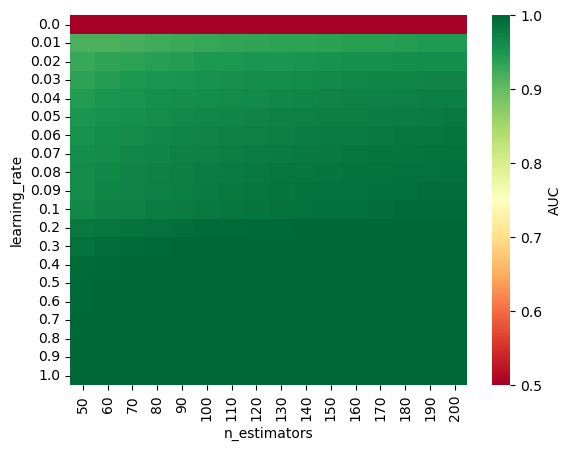

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(
    data = df_model.pivot(
        index = 'learning_rate',
        columns = 'n_estimators',
        values = 'Train'
    ),
    annot=False,
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1,
    cbar_kws={'label': 'AUC'}
)

<Axes: xlabel='n_estimators', ylabel='learning_rate'>

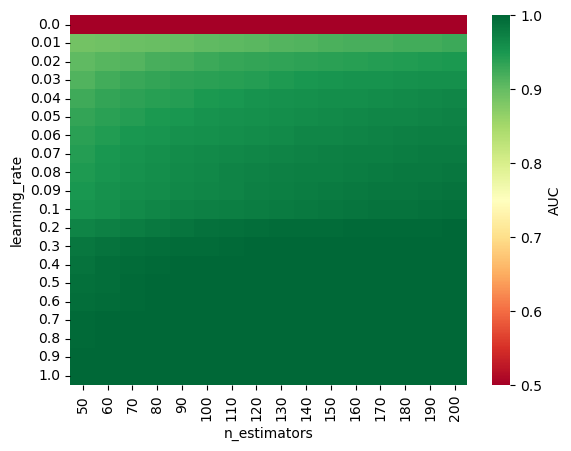

In [66]:
sns.heatmap(
    data = df_model.pivot(
        index = 'learning_rate',
        columns = 'n_estimators',
        values = 'Validation'
    ),
    annot=False,
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1,
    cbar_kws={'label': 'AUC'}
)

<Axes: xlabel='n_estimators', ylabel='learning_rate'>

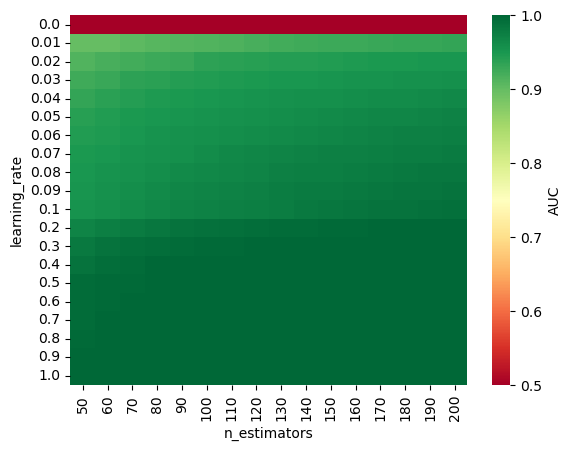

In [68]:
sns.heatmap(
    data = df_model.pivot(
        index = 'learning_rate',
        columns = 'n_estimators',
        values = 'Test'
    ),
    annot=False,
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1,
    cbar_kws={'label': 'AUC'}
)

# Isolate best performing models

In [70]:
df_select = df_model
df_select = df_select.loc[df_select['Test'] > 0.99]
df_select = df_select.loc[df_select['Validation'] > 0.99]
df_select = df_select.loc[df_select['Train'] > 0.99]
df_select

,learning_rate,n_estimators,GradientBoostingClassifier,fit,Train,Validation,Test
175,0.1,200,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.995536,0.990280,0.990917
182,0.2,110,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.995314,0.990734,0.990547
183,0.2,120,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.996759,0.992670,0.992831
184,0.2,130,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.997363,0.994260,0.994889
185,0.2,140,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.998441,0.995113,0.995537
...,...,...,...,...,...,...,...
315,1.0,160,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,1.000000,1.000000,1.000000
316,1.0,170,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,1.000000,1.000000,1.000000
317,1.0,180,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,1.000000,1.000000,1.000000
318,1.0,190,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,1.000000,1.000000,1.000000


# Of the best performing models, select the simpliest one

In [72]:
df_select = df_select.loc[df_select['n_estimators'] == df_select['n_estimators'].min()]
df_select = df_select.loc[df_select['learning_rate'] == df_select['learning_rate'].min()]
df_select

,learning_rate,n_estimators,GradientBoostingClassifier,fit,Train,Validation,Test
224,0.5,50,([DecisionTreeRegressor(criterion='friedman_ms...,([DecisionTreeRegressor(criterion='friedman_ms...,0.996185,0.991478,0.994288


I am so happy I got past that error. A huge relief, and since projects 13 and 14 are also tree projects I can just save this dataframe at the end and use it on those projects.

# Feature importance

The `feature_importances_` attribute in scikit-learn's Gradient Boosting models (`GradientBoostingClassifier` and `GradientBoostingRegressor`) provides a measure of the importance of each feature in the model. 

This importance is calculated based on how much each feature contributes to reducing the impurity (or error) across all the trees in the ensemble. 

The calculation follows these steps:

# Impurity Reduction

For each decision tree in the gradient boosting model, feature importance is determined by the reduction in impurity (or error) it achieves. The impurity reduction is calculated at each split in the tree.

* Classification (Gini Impurity):

The Gini impurity for a node $t$ is given by:

$$
I(t) = 1 - \sum_{k=1}^{K} p_{k}^{2}
$$

where $p_{k}$ is the proportion of class $k$ instances in the node.

* For Regression (Mean Squared Error):

The mean squared error (MSE) for a node $t$ is given by:

$$
I(t) = \frac{1}{N_t} \sum_{i=1}^{N_t} (y_i - \bar{y})^2
$$

where $N_t$ is the number of instances in the node, $y_i$ are the target values, and $\bar{y}$ is the mean target value in the node.

# Weighted Impurity Reduction

For each split in the tree that uses a feature $j$, the importance of the feature is the weighted impurity reduction:

$$
\Delta I(t, j) = I(t) - \left( \frac{N_{t_L}}{N_t} I(t_L) + \frac{N_{t_R}}{N_t} I(t_R) \right)
$$

where:

- $t$ is the parent node,
- $t_L$ and $t_R$ are the left and right child nodes,
- $N_t$, $N_{t_L}$, and $N_{t_R}$ are the number of instances in the parent, left child, and right child nodes, respectively.

# Aggregating Over All Trees

The importance of a feature $j$ across all trees in the ensemble is the sum of the weighted impurity reductions for that feature over all splits and all trees:

$$
\text{Importance}(j) = \sum_{m=1}^{M} \sum_{t \in T_m} \Delta I(t, j)
$$

where:
- $M$ is the number of trees in the ensemble,
- $T_m$ is the set of all nodes in tree $m$.

# Normalizing Feature Importances

The raw importance scores are normalized so that they sum to 1.

- Impurity Reduction: Feature importance is based on the reduction in impurity (Gini for classification, MSE for regression) a feature achieves in each tree.
- Weighted Sum: The reductions are weighted by the number of instances in the split nodes and summed over all trees in the ensemble.
- Normalization: The raw importance scores are normalized so that the total importance sums to 1.

# Short coming of tree model feature importance

Rare events that have large impacts on the dependent variable will have lower feature importance than in linear models.

For example, bankruptcy is a rare event but will have a huge coefficient in a logistic regression collections model. Bankruptcy may actually get pushed out of a tree model during backwards elimination because of its rarity. (Dr. Smith experienced this professionally.)

In [75]:
GradientBoostingClassifier_final = df_select['fit'].values[0]
df_feature_importances_ = pd.DataFrame({
    'feature_names_in_' : GradientBoostingClassifier_final.feature_names_in_,
    'feature_importances_' : GradientBoostingClassifier_final.feature_importances_
}).sort_values('feature_importances_',ascending = False)
df_feature_importances_['cumsum'] = np.cumsum(
    a = df_feature_importances_['feature_importances_']
)
df_feature_importances_

,feature_names_in_,feature_importances_,cumsum
0,px,0.391598,0.391598
1,pz,0.196823,0.588421
20,y,0.114209,0.702631
12,sz_bot,0.033560,0.736190
17,vz0,0.023642,0.759833
...,...,...,...
39,zone_8.0,0.000000,1.000000
40,zone_9.0,0.000000,1.000000
47,pitch_type_EP,0.000000,1.000000
46,pitch_type_CU,0.000000,1.000000


It looks like position is the most important feature here. It makes sense why it's importance went up when I ungrouped the zone columns.

# Feature importance is rescaled to one

In [78]:
np.sum(
    a = GradientBoostingClassifier_final.feature_importances_
)

0.9999999999999997

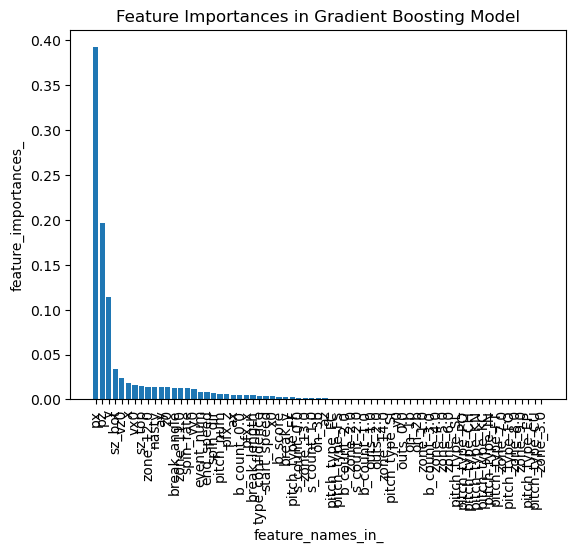

In [80]:
import matplotlib.pyplot as plt
plt.bar(df_feature_importances_['feature_names_in_'], df_feature_importances_['feature_importances_'])
plt.xlabel('feature_names_in_')
plt.ylabel('feature_importances_')
plt.title('Feature Importances in Gradient Boosting Model')
plt.xticks(rotation=90)
plt.show()

# Using gradient boosting to detect interactions

Ensemble tree models do a good job a detecting interactions between predictor variables. Unfortunately, these models do not directly tell us which interactions are present. We can use predictions from these models to create contours plot to visualized interactions.

* The more the contour plot does not look like parallel straight lines, the more the plot indicates that there is an interaction.
* This approach heavily depends on the model sufficiently detecting interactions.
* Contour lines looking like hyperbolas (like y = 1/x) is extreme evidence for interactions.
* Use these two plots to see what extreme evidence against and for interactions looks like.
  - No interaction: z = x + y
  - Interaction: z = x + y + x*y

For GradientBoostingClassifier and GradientBoostingRegressor, the 'recursion' method (used by default) will not account for the init predictor of the boosting process. In practice, this will produce the same values as 'brute' up to a constant offset in the target response, provided that init is a constant estimator (which is the default). However, if init is not a constant estimator, the partial dependence values are incorrect for 'recursion' because the offset will be sample-dependent. It is preferable to use the 'brute' method. Note that this only applies to GradientBoostingClassifier and GradientBoostingRegressor, not to HistGradientBoostingClassifier and HistGradientBoostingRegressor.

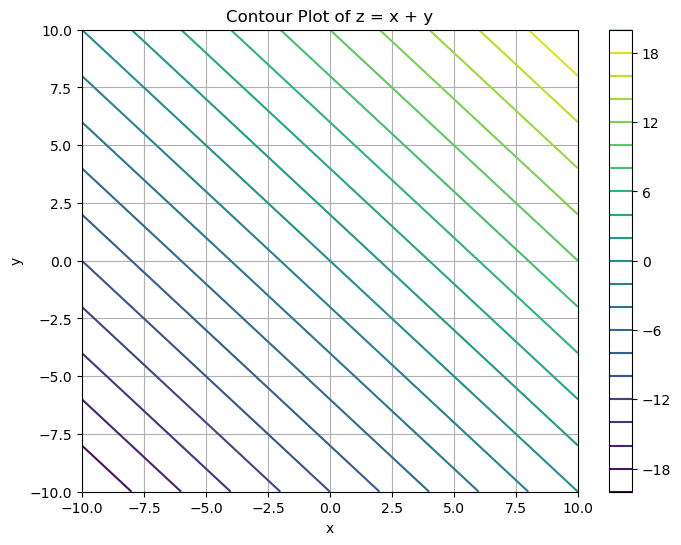

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid of x and y values
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

# Define the function z = x + y
Z = X + Y

# Create the contour plot
plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(contour)
plt.title('Contour Plot of z = x + y')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

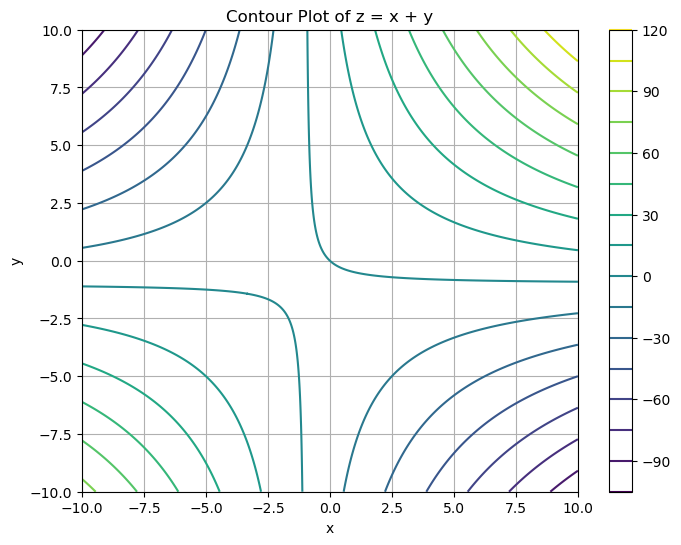

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid of x and y values
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

# Define the function z = x + y
Z = X + Y + X*Y

# Create the contour plot
plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(contour)
plt.title('Contour Plot of z = x + y')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [ ]:
#from sklearn.inspection import partial_dependence,PartialDependenceDisplay
#for j in range(len(X_Train.columns)):
#    for k in range(len(X_Train.columns)):
#        try:
#            PartialDependenceDisplay.from_estimator(
#                estimator = GradientBoostingClassifier_final,
#                X = X_Train,
#                features = [j,k,(j,k)],
#                method = 'brute')
#       except Exception as e:
#            pass

# This loads a lot of graphs.

In [93]:
df.to_csv(
    path_or_buf = 'C:\\Users\\brand\\jupyter notebook stuff\\pitches_prepared_tree_c.csv',
    index = False
)

df.to_csv(
    path_or_buf = 'C:\\Users\\brand\\jupyter notebook stuff\\pitches_prepared_tree_r.csv',
    index = False
)